In [ ]:
import numpy as np
import matplotlib.pyplot as plt

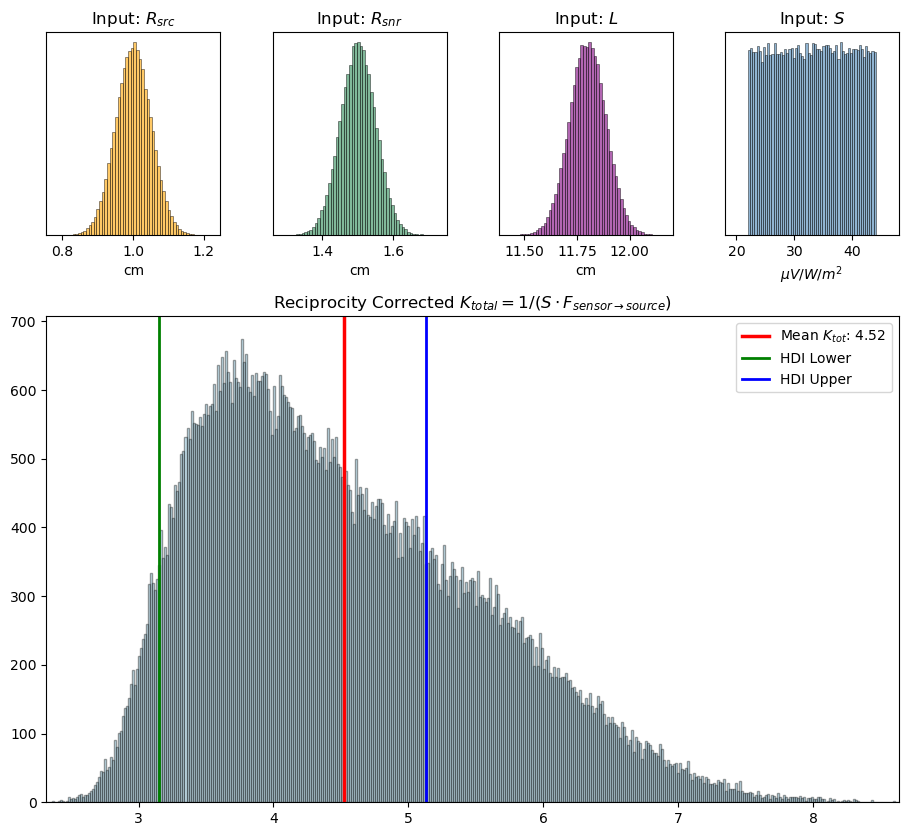

Mean Calibration Factor: 4.5206
68% HDI: [3.1501, 5.1329]


In [1]:
# --- 1. Inputs & Nominal Values ---
n_iter = 100000 
np.random.seed(42)

#R_src_nom, R_snr_nom, L_nom = 1, 1.5, 7 #estimated values: 
R_src_nom, R_snr_nom, L_nom = 1, 1.5, 11.8 #new values
tol_R = 0.05
tol_L = 0.087  # Summed in quadrature

# Manufacturer Specs
S1_min, S1_max, S1_nom = 22.0, 44.0, 33.0

# --- 2. Generate Distributions ---
r_src_sim = np.random.normal(R_src_nom, tol_R, n_iter)
r_snr_sim = np.random.normal(R_snr_nom, tol_R, n_iter)
L_sim     = np.random.normal(L_nom, tol_L, n_iter)
S_sim     = np.random.uniform(S1_min, S1_max, n_iter)

# --- 3. View factor Calculations ---
def get_view_factor(r_emit, r_receive, d):
    """Calculates fraction of energy leaving r_emit that hits r_receive"""
    X = 1 + (d**2 / r_emit**2) + (r_receive/r_emit)**2
    return 0.5 * (X - np.sqrt(X**2 - 4 * (r_receive/r_emit)**2))

# F21 is the fraction of the SENSOR'S view occupied by the OVEN
f21_sim = get_view_factor(r_snr_sim, r_src_sim, L_sim)

# K = 1 / (S * F21)
K_tot_sim = 1 / (S_sim * f21_sim)

# Stats for K_tot (Mean & HDI)
K_tot_expected = np.mean(K_tot_sim)
sorted_Kt = np.sort(K_tot_sim)
win = int(0.68 * n_iter)
idx_t = np.argmin(sorted_Kt[win:] - sorted_Kt[:-win])
K_tot_low, K_tot_up = sorted_Kt[idx_t], sorted_Kt[idx_t + win]

# K_sens for Preliminary Plot 3 (M_sensor = V * K_sens)
K_sens_sim = 1 / S_sim
K_sens_expected = np.mean(K_sens_sim)
sorted_Ks = np.sort(K_sens_sim)
idx_s = np.argmin(sorted_Ks[win:] - sorted_Ks[:-win])
K_sens_low, K_sens_up = sorted_Ks[idx_s], sorted_Ks[idx_s + win]

# --- 4. Plotting ---
fig = plt.figure(figsize=(11, 10))
grid = plt.GridSpec(3, 4, hspace=0.4, wspace=0.3)

# Inputs
params = [(r_src_sim, r'$R_{src}$', 'cm', 'orange'), (r_snr_sim, r'$R_{snr}$', 'cm', 'seagreen'),
          (L_sim, r'$L$', 'cm', 'purple'), (S_sim, r'$S$', r'$\mu V/W/m^2$', 'steelblue')]
for i, (data, name, unit, color) in enumerate(params):
    ax = fig.add_subplot(grid[0, i])
    ax.hist(data, bins=60, color=color, alpha=0.6, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Input: {name}')
    ax.set_xlabel(unit); ax.set_yticks([])
    if name == r'$S$': ax.set_xlim(S1_min - 4, S1_max + 4)

# Results
ax_res = fig.add_subplot(grid[1:, :])
ax_res.hist(K_tot_sim, bins=500, color='skyblue', edgecolor='black', alpha=0.4)
ax_res.axvline(K_tot_expected, color='red', linewidth=2.5, label=rf'Mean $K_{{tot}}$: {K_tot_expected:.2f}')
ax_res.axvline(K_tot_low, color='green', linewidth=2, label='HDI Lower')
ax_res.axvline(K_tot_up, color='blue', linewidth=2, label='HDI Upper')
ax_res.set_xlim(np.percentile(K_tot_sim, 0), np.percentile(K_tot_sim, 99.99))
ax_res.set_title(r'Reciprocity Corrected $K_{total} = 1 / (S \cdot F_{sensor \to source})$')
ax_res.legend(); plt.show()

print(f"Mean Calibration Factor: {K_tot_expected:.4f}")
print(f"68% HDI: [{K_tot_low:.4f}, {K_tot_up:.4f}]")

In [ ]:
import pandas as pd
from scipy.optimize import curve_fit

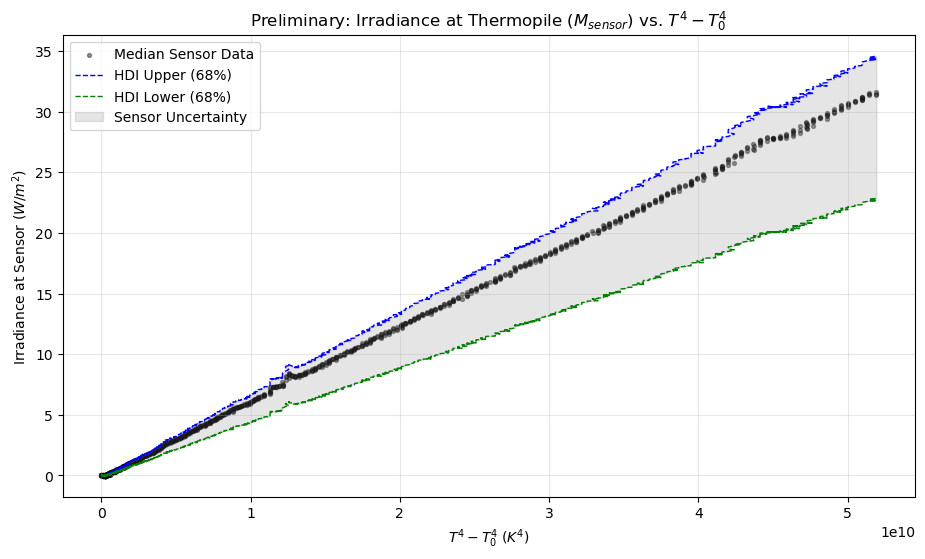

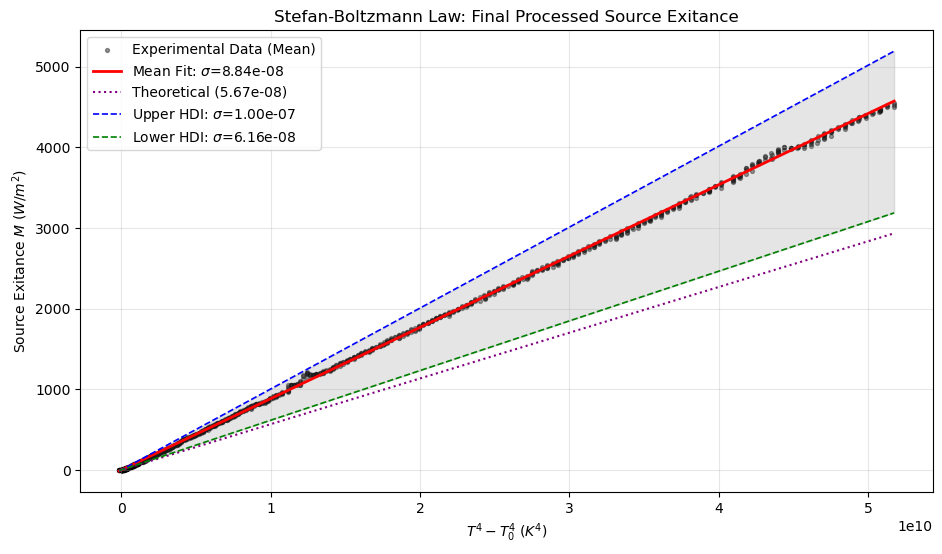

------------------------------
Calculated Sigma: 8.8397e-08 W/m^2K^4
68% HDI Uncertainty Range: [6.1599e-08, 1.0037e-07]
------------------------------
ACCURACY RATIO (Exp/Theory): 1.5589
My result is 55.9% away from the theoretical value.
------------------------------


In [3]:
# --- 1. Data Processing ---
df = pd.read_csv('oven data.csv')
v_corr = df["Voltage U_B1' / mV"].to_numpy() - 0.016
V_uv = v_corr * 1000
T_k = df["Temperature &J_A11 / °C"].to_numpy() + 273.15
T0 = 29 + 273.15
X_prelim = T_k**4 - T0**4

def sb_model(T, sigma_fit, T0_fit): 
    return sigma_fit * (T**4 - T0_fit**4)

# --- 2. Preliminary Graph: Irradiance at Thermopile (M_sensor) ---
M_snr_expected = V_uv * K_sens_expected
M_snr_low = V_uv * K_sens_low
M_snr_up = V_uv * K_sens_up

plt.figure(figsize=(11, 6))
plt.scatter(X_prelim, M_snr_expected, color='black', s=8, alpha=0.4, label='Median Sensor Data')
plt.plot(X_prelim, M_snr_up, 'b--', linewidth=1, label='HDI Upper (68%)')
plt.plot(X_prelim, M_snr_low, 'g--', linewidth=1, label='HDI Lower (68%)')
plt.fill_between(X_prelim, M_snr_low, M_snr_up, color='gray', alpha=0.2, label='Sensor Uncertainty')

plt.title(r'Preliminary: Irradiance at Thermopile ($M_{sensor}$) vs. $T^4 - T_0^4$')
plt.xlabel(r'$T^4 - T_0^4$ ($K^4$)'); plt.ylabel(r'Irradiance at Sensor ($W/m^2$)')
plt.legend(loc='upper left'); plt.grid(True, alpha=0.3); plt.show()

# --- 3. Final Graph: Irradiance at Source (M_source) ---
M_source_mean = V_uv * K_tot_expected
p_mean, _ = curve_fit(sb_model, T_k, M_source_mean, p0=[5.67e-8, T0])

M_source_low = V_uv * K_tot_low
M_source_up  = V_uv * K_tot_up
p_low, _ = curve_fit(sb_model, T_k, M_source_low, p0=[5.67e-8, T0])
p_up, _  = curve_fit(sb_model, T_k, M_source_up, p0=[5.67e-8, T0])

# --- 4. Accuracy Calculation ---
sigma_theory = 5.67037e-8
accuracy_ratio = p_mean[0] / sigma_theory

# --- 5. Plotting Final Results ---
plt.figure(figsize=(11, 6))
t_plot = np.linspace(T_k.min(), T_k.max(), 500)
x_plot = t_plot**4 - p_mean[1]**4 

plt.scatter(T_k**4 - p_mean[1]**4, M_source_mean, color='black', s=8, alpha=0.4, label='Experimental Data (Mean)')
plt.plot(x_plot, sb_model(t_plot, *p_mean), 'r-', linewidth=2, label=rf'Mean Fit: $\sigma$={p_mean[0]:.2e}')
plt.plot(x_plot, sigma_theory * x_plot, color='purple', linestyle=':', label='Theoretical (5.67e-08)')

plt.plot(x_plot, sb_model(t_plot, *p_up), 'b--', linewidth=1.2, label=rf'Upper HDI: $\sigma$={p_up[0]:.2e}')
plt.plot(x_plot, sb_model(t_plot, *p_low), 'g--', linewidth=1.2, label=rf'Lower HDI: $\sigma$={p_low[0]:.2e}')
plt.fill_between(x_plot, sb_model(t_plot, *p_low), sb_model(t_plot, *p_up), color='gray', alpha=0.2)

plt.title('Stefan-Boltzmann Law: Final Processed Source Exitance')
plt.xlabel(r'$T^4 - T_0^4$ ($K^4$)'); plt.ylabel(r'Source Exitance $M$ ($W/m^2$)')
plt.legend(loc='upper left'); plt.grid(True, alpha=0.3); plt.show()

# --- 6. Final Outputs ---
print("-" * 30)
print(f"Calculated Sigma: {p_mean[0]:.4e} W/m^2K^4")
print(f"68% HDI Uncertainty Range: [{p_low[0]:.4e}, {p_up[0]:.4e}]")
print("-" * 30)
print(f"ACCURACY RATIO (Exp/Theory): {accuracy_ratio:.4f}")
print(f"My result is {abs(1 - accuracy_ratio)*100:.1f}% away from the theoretical value.")
print("-" * 30)